In [4]:
import sys
from utils import export_mft
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pickle
import plotly.graph_objects as go


sys.path.append('..')
from config import DATA_PATH
from pathlib import Path

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

# get the fitted PCA model
with open("../data_prep/pkl-files/pca_model.pkl", "rb") as f:
    pca_full = pickle.load(f)

# get the train contours (raw trajectory data)
with open("../data_prep/pkl-files/train_contours.pkl", "rb") as f:
    train_contours = pickle.load(f)

# get the test contours (raw trajectory data)
with open("../data_prep/pkl-files/test_contours.pkl", "rb") as f:
    test_contours = pickle.load(f)

# get saved scaler
with open("../data_prep/pkl-files/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("loaded pca model, n_components available:", pca_full.n_components_)
print(f"loaded {len(train_contours)} train contours, {len(test_contours)} test contours")
print("imports completed!")

loaded pca model, n_components available: 100
loaded 19498 train contours, 2147 test contours
imports completed!


In [3]:
# load full contours and build resampled_trajectories for real training

with open("../data_prep/pkl-files/train_contours.pkl", "rb") as f:
    contours = pickle.load(f)

def resample_trajectory(freqs, n_points=100):
    if len(freqs) < 2:
        return None
    x_old = np.linspace(0, 1, len(freqs))
    x_new = np.linspace(0, 1, n_points)
    f = interp1d(x_old, freqs, kind="linear")
    return f(x_new)

train_resampled_trajectories = []
for key, data in contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        train_resampled_trajectories.append(result)

print(f"resampled {len(train_resampled_trajectories)} out of {len(contours)} trajectories")

test_resampled_trajectories = []
for key, data in test_contours.items():
    result = resample_trajectory(data["frequency_hz"])
    if result is not None:
        test_resampled_trajectories.append(result)

print(f"resampled {len(test_resampled_trajectories)} out of {len(test_contours)} test trajectories")

resampled 19498 out of 19498 trajectories
resampled 2147 out of 2147 test trajectories


In [6]:
all_trajectories_arr = np.array(train_resampled_trajectories)
means = all_trajectories_arr.mean(axis=1, keepdims=True)
centered = all_trajectories_arr - means
pca_coords = pca_full.transform(centered)[:, :3]

fig = go.Figure(data=[go.Scatter3d(
    x=pca_coords[:, 0],
    y=pca_coords[:, 1],
    z=pca_coords[:, 2],
    mode='markers',
    marker=dict(size=2, opacity=0.4),
    text=[f"trajectory {i}" for i in range(len(pca_coords))],  # shows on hover
    hoverinfo='text'
)])

fig.update_layout(
    title="pca space of all real usv trajectories",
    scene=dict(
        xaxis_title="pc1", yaxis_title="pc2", zaxis_title="pc3",
        camera=dict(eye=dict(x=1.0, y=1.0, z=1.0))  # closer default view than plotly's usual 1.25/1.25/1.25
    ),
    width=1000, height=800  # bigger plot area = more sensitive-feeling drag/scroll
)

fig.show()

In [ ]:
from sklearn.decomposition import PCA

X = np.stack(train_resampled_trajectories)
print("Data matrix shape:", X.shape)  # should be (19498, 100)

X_centered = X - X.mean(axis=1, keepdims=True)

pca_full = PCA()
pca_full.fit(X_centered)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative variance at 1, 2, 3, 5, 10 components:")
print(cumulative_variance[0], cumulative_variance[1], cumulative_variance[2], cumulative_variance[4], cumulative_variance[9])

Data matrix shape: (19498, 100)
Cumulative variance at 1, 2, 3, 5, 10 components:
0.4635432035942505 0.6823068715893217 0.7712341011090754 0.8601675974960202 0.9336139566131766


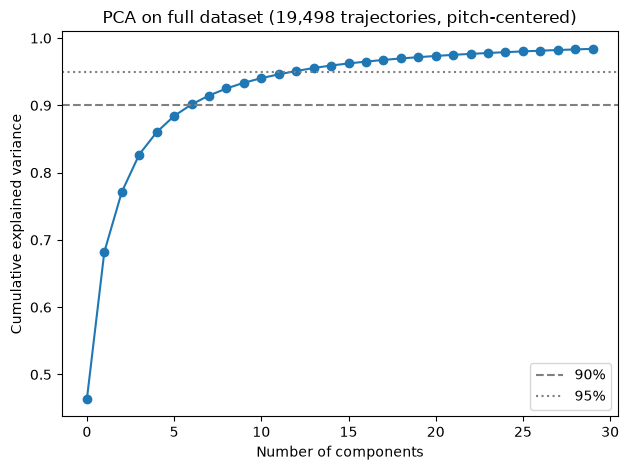

In [ ]:
plt.plot(cumulative_variance[:30], marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='gray', linestyle='--', label='90%')
plt.axhline(0.95, color='gray', linestyle=':', label='95%')
plt.legend()
plt.title("PCA on full dataset (19,498 trajectories, pitch-centered)")
plt.tight_layout()
plt.show()

In [ ]:
# # flag problem files
 
# from utils import flag_mft_dataset

# all_train_files = sorted(TRAIN_PATH.glob("*.WAV"))
# print(f"Total files: {len(all_train_files)}")

# flagged_df = flag_mft_dataset(all_train_files, output_csv="portable-data/flagged_mfts.csv")

In [ ]:
# # exclude the flagged problem files, then extract + save real frequency
# # trajectories for all remaining clean files into one pickle file

# from utils import export_mft_pickle

# import pandas as pd

# flagged_df = pd.read_csv("portable-data/flagged_mfts.csv")
# print(f"Loaded {len(flagged_df)} flagged files")

# flagged_names = set(flagged_df["filename"])
# clean_files = [f for f in all_train_files if f.name not in flagged_names]
# print(f"Exporting {len(clean_files)} clean files")

# export_mft_pickle(clean_files, output_file="pkl-files/sep_14_contours.pkl")

In [ ]:
# from utils import flag_mft_dataset

# all_test_files = sorted(TEST_PATH.glob("*.WAV"))
# print(f"Total test files: {len(all_test_files)}")

# flagged_test_df = flag_mft_dataset(all_test_files, output_csv="portable-data/flagged_test_mfts.csv")
# print(f"Flagged {len(flagged_test_df)} out of {len(all_test_files)}")

Total test files: 2251
Flagged 104 files.
Saved to: portable-data/flagged_test_mfts.csv
Flagged 104 out of 2251


In [ ]:
# # exclude flagged files, export the clean test set
# from utils import export_mft_pickle

# flagged_test_names = set(flagged_test_df["filename"])
# clean_test_files = [f for f in all_test_files if f.name not in flagged_test_names]
# print(f"Exporting {len(clean_test_files)} clean test files")

# export_mft_pickle(clean_test_files, output_file="pkl-files/test_contours.pkl")

Exporting 2147 clean test files


'pkl-files/test_contours.pkl'